<a href="https://colab.research.google.com/github/holohunnid/FinancialModeling-Black-Litterman-RiskParityAllocation/blob/main/black_litterman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Black-Litterman Portfolio Optimization via Regression-Based Views**

### A quantitative framework for deriving investor views from multi-factor regression models
---

**Author:** Alain Fontana — SUPSI, Bachelor in Economia aziendale

**Supervisor:** Fabiano Cavadini

# **Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
import yfinance as yf
from pandas_datareader import data as pdr
import statsmodels.api as sm
from scipy.optimize import minimize
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import itertools
import warnings
from prettytable import PrettyTable, SINGLE_BORDER

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 100,
})

SECTOR_COLORS = {
    'Technology': '#4E79A7', 'Financials': '#F28E2B', 'Healthcare': '#E15759',
    'Energy': '#76B7B2', 'Consumer Staples': '#59A14F', 'Industrials': '#EDC948',
    'Consumer Discretionary': '#B07AA1'
}

/tmp/ipykernel_17000/95239074.py:14: DeprecationWarning: the 'SINGLE_BORDER' constant is deprecated, use the 'TableStyle' enum instead
  from prettytable import PrettyTable, SINGLE_BORDER


# **Global Configuration**

In [2]:
TICKERS = ['AAPL','MSFT','NVDA','JPM','GS','JNJ','UNH','XOM','CVX',
           'KO','PG','CAT','HON','AMZN','TSLA']

SECTORS = {
    'AAPL': 'Technology', 'MSFT': 'Technology', 'NVDA': 'Technology',
    'JPM': 'Financials', 'GS': 'Financials',
    'JNJ': 'Healthcare', 'UNH': 'Healthcare',
    'XOM': 'Energy', 'CVX': 'Energy',
    'KO': 'Consumer Staples', 'PG': 'Consumer Staples',
    'CAT': 'Industrials', 'HON': 'Industrials',
    'AMZN': 'Consumer Discretionary', 'TSLA': 'Consumer Discretionary'
}

N_ASSETS         = len(TICKERS)
BENCHMARK_TICKER = 'SPY'

BASELINE_START = '2020-01-01'
BASELINE_END   = '2025-12-31'
FREQ           = 'W'

DOWNLOAD_START = '2019-01-01'
DOWNLOAD_END   = '2025-12-31'

WINDOW_CONFIGS = {
    '3yr': ('2023-01-01', '2025-12-31'),
    '5yr': ('2021-01-01', '2025-12-31'),
    '6yr': ('2020-01-01', '2025-12-31'),
    '7yr': ('2019-01-01', '2025-12-31'),
}

STABILITY_PERIOD_1 = ('2020-01-01', '2022-12-31')
STABILITY_PERIOD_2 = ('2023-01-01', '2025-12-31')

TAU_BASELINE          = 0.025
PVALUE_BASELINE       = 0.05
R2_ADJ_BASELINE       = 0.15
FACTOR_MODEL_BASELINE = 'FF5'
OMEGA_METHOD_BASELINE = 'scherer'

TAU_GRID    = [0.001, 0.01, 0.025, 0.05]
PVALUE_GRID = [0.01, 0.05, 0.10]
R2_GRID     = [0.10, 0.15, 0.20, 0.30]
K_GRID      = [3, 5, 7, 10, 'all']

print(f"Universe: {N_ASSETS} assets | Benchmark: {BENCHMARK_TICKER}")
print(f"Baseline window: {BASELINE_START} to {BASELINE_END} (weekly)")

Universe: 15 assets | Benchmark: SPY
Baseline window: 2020-01-01 to 2025-12-31 (weekly)


# **Table Rendering Utilities**

In [3]:
def make_pretty(title, columns, rows, align_map=None):
    t = PrettyTable()
    t.set_style(SINGLE_BORDER)
    t.title = title
    t.field_names = columns
    for col in columns:
        t.align[col] = align_map.get(col, 'r') if align_map else ('l' if col == columns[0] else 'r')
    for row in rows:
        formatted = []
        for val in row:
            if isinstance(val, float):
                if abs(val) > 1e6:
                    formatted.append(f"{val:,.0f}")
                elif abs(val) > 1:
                    formatted.append(f"{val:.2f}")
                else:
                    formatted.append(f"{val:.4f}")
            else:
                formatted.append(str(val))
        t.add_row(formatted)
    return t

def style_dataframe(df, fmt='{:.4f}', cmap='RdYlGn', highlight_cols=None):
    styled = df.style.format(fmt)
    styled = styled.set_properties(**{'text-align': 'right', 'font-size': '11px'})
    styled = styled.set_table_styles([
        {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center'), ('font-size', '12px')]},
    ])
    if highlight_cols:
        styled = styled.background_gradient(cmap=cmap, subset=highlight_cols)
    return styled

---

# **Section I — Data Acquisition and Preparation**

This section transforms raw market data into the fundamental inputs for the Black-Litterman model: weekly log returns, sample covariance matrix, market capitalisation weights, risk aversion coefficient $\delta$, and the equilibrium return vector $\Pi = \delta \Sigma w_{mkt}$.

## 1.1 Price Data Download

In [4]:
all_tickers = TICKERS + [BENCHMARK_TICKER]
prices_raw = yf.download(all_tickers, start=DOWNLOAD_START, end=DOWNLOAD_END,
                         interval='1wk', auto_adjust=True)['Close']
prices_raw = prices_raw[all_tickers]
prices_raw.dropna(inplace=True)

print(f"Price data: {prices_raw.index[0].date()} to {prices_raw.index[-1].date()}")
print(f"Shape: {prices_raw.shape[0]} weeks x {prices_raw.shape[1]} tickers")
print(f"Missing values: {prices_raw.isna().sum().sum()}")

[*********************100%***********************]  16 of 16 completed

Price data: 2019-01-01 to 2025-12-30
Shape: 366 weeks x 16 tickers
Missing values: 0


In [5]:
prices_raw.tail(10)

Ticker,AAPL,MSFT,NVDA,JPM,GS,JNJ,UNH,XOM,CVX,KO,PG,CAT,HON,AMZN,TSLA,SPY
Date,,,,,,,,,,,,,,,,
2025-10-28,268.538147,514.888916,206.857285,307.960876,777.552979,184.106125,329.002991,112.026917,150.862808,67.034988,146.976471,569.258118,195.621307,254.000000,468.369995,679.471130
2025-11-04,268.917450,503.904572,199.028152,315.467010,789.114502,186.231277,316.968079,116.418968,152.439606,69.549911,144.474228,569.517456,193.939774,248.399994,445.230011,677.581848
2025-11-11,267.209961,505.388397,186.579514,299.021179,767.693970,197.272095,315.923279,115.887192,151.626740,69.707710,144.791977,550.761353,193.949661,232.869995,408.920013,661.901123
2025-11-18,275.662079,472.037109,182.529968,296.661835,782.690308,203.667282,314.474365,115.202133,146.661301,71.591431,145.943787,558.293762,187.727982,226.279999,417.779999,664.943787
2025-11-25,282.835358,485.631561,179.900253,307.532806,802.635925,202.965485,318.574738,115.857765,151.062241,70.960236,146.400558,566.734009,189.280273,233.880005,430.140015,676.418457
2025-12-02,277.630219,489.901825,185.529633,313.794556,857.899658,200.553833,318.978851,115.212074,147.269363,69.770264,137.364700,595.107605,191.041534,226.889999,439.579987,679.759460
2025-12-09,273.853729,473.738708,176.280457,318.582947,884.932861,213.037460,338.468658,116.980286,148.348801,70.485344,144.106842,588.383362,196.474548,222.539993,475.309998,676.875854
2025-12-16,270.716675,483.815735,183.680054,321.639160,894.293579,206.223694,322.651611,117.367699,148.348801,69.730530,141.684036,581.050476,194.991928,228.429993,488.730011,680.952698
2025-12-23,273.504089,485.990753,188.209808,322.296204,887.509277,206.462418,326.402435,119.731941,149.527267,69.680878,143.550797,577.259399,196.116333,232.070007,459.640015,685.976562


## 1.2 Weekly Log Returns

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

In [6]:
log_returns_full = np.log(prices_raw / prices_raw.shift(1)).dropna()

returns = log_returns_full.loc[BASELINE_START:BASELINE_END, TICKERS].copy()
returns_spy = log_returns_full.loc[BASELINE_START:BASELINE_END, BENCHMARK_TICKER].copy()

print(f"Weekly log returns: {returns.shape[0]} observations x {returns.shape[1]} assets")
print(f"Date range: {returns.index[0].date()} to {returns.index[-1].date()}")

Weekly log returns: 313 observations x 15 assets
Date range: 2020-01-07 to 2025-12-30


## 1.3 Fama-French Factor Data

Daily factor returns from the Kenneth French Data Library, compounded to weekly frequency.

In [7]:
ff3_daily = pdr.DataReader('F-F_Research_Data_Factors_daily', 'famafrench',
                          start=DOWNLOAD_START, end=DOWNLOAD_END)[0] / 100
ff5_daily = pdr.DataReader('F-F_Research_Data_5_Factors_2x3_daily', 'famafrench',
                          start=DOWNLOAD_START, end=DOWNLOAD_END)[0] / 100

ff3_daily.index = pd.to_datetime(ff3_daily.index.astype(str))
ff5_daily.index = pd.to_datetime(ff5_daily.index.astype(str))

def compound_to_weekly(daily_df, weekly_index):
    result = pd.DataFrame(index=weekly_index, columns=daily_df.columns, dtype=float)
    dates = list(weekly_index)
    for i in range(len(dates)):
        start = dates[i-1] if i > 0 else daily_df.index[0]
        end = dates[i]
        mask = (daily_df.index > start) & (daily_df.index <= end)
        window = daily_df.loc[mask]
        if len(window) > 0:
            result.loc[end] = (1 + window).prod() - 1
    return result.dropna()

ff3_weekly = compound_to_weekly(ff3_daily, prices_raw.index)
ff5_weekly = compound_to_weekly(ff5_daily, prices_raw.index)

ff3 = ff3_weekly.loc[BASELINE_START:BASELINE_END].copy()
ff5 = ff5_weekly.loc[BASELINE_START:BASELINE_END].copy()

rf_weekly = ff3['RF']
rf_annual_avg = (1 + rf_weekly.mean())**52 - 1

ff3_factors = ff3[['Mkt-RF', 'SMB', 'HML']]
ff5_factors = ff5[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]

factors = ff5_factors if FACTOR_MODEL_BASELINE == 'FF5' else ff3_factors

# Align all indices
common_idx = returns.index.intersection(factors.index)
returns = returns.loc[common_idx]
returns_spy = returns_spy.loc[common_idx]
factors = factors.loc[common_idx]
rf_weekly = rf_weekly.loc[common_idx]

print(f"Factor data aligned: {factors.shape[0]} obs x {factors.shape[1]} factors ({FACTOR_MODEL_BASELINE})")
print(f"Mean weekly r_f: {rf_weekly.mean():.6f} (annualised: {rf_annual_avg:.4f})")

Factor data aligned: 313 obs x 5 factors (FF5)
Mean weekly r_f: 0.000541 (annualised: 0.0285)


In [8]:
factors.tail(10)

,Mkt-RF,SMB,HML,RMW,CMA
Date,,,,,
2025-10-28,0.021482,-0.009012,-0.013519,0.006105,-0.024433
2025-11-04,-0.019262,-0.019676,0.008934,0.000539,-0.006526
2025-11-11,0.010153,0.002617,0.014028,-0.000375,0.012039
2025-11-18,-0.035596,-0.006459,0.009112,0.005878,0.000087
2025-11-25,0.024325,0.032821,-0.002592,0.005076,-0.006577
2025-12-02,0.009087,-0.011258,0.008819,0.000029,0.001200
2025-12-09,0.003186,0.018558,-0.003222,-0.025481,-0.011861
2025-12-16,-0.007267,0.007450,0.026824,0.013527,0.016460
2025-12-23,0.015449,-0.012575,-0.010030,-0.006690,-0.008558


## 1.4 Market Capitalisation Weights

$$w_i^{mkt} = \frac{\text{MarketCap}_i}{\sum_j \text{MarketCap}_j}$$

In [9]:
info_data = {}
for ticker in TICKERS:
    t = yf.Ticker(ticker)
    info = t.info
    shares = info.get('sharesOutstanding', None)
    info_data[ticker] = shares

last_prices = prices_raw[TICKERS].iloc[-1]
market_caps = pd.Series({t: last_prices[t] * info_data[t] for t in TICKERS if info_data[t]})
w_mkt = market_caps / market_caps.sum()

rows = []
for t in w_mkt.sort_values(ascending=False).index:
    rows.append([t, SECTORS[t], market_caps[t]/1e9, w_mkt[t]*100])

tbl = make_pretty("Market Capitalisation Weights",
                  ["Ticker", "Sector", "Mkt Cap ($B)", "Weight (%)"], rows,
                  align_map={"Ticker": "l", "Sector": "l"})
print(tbl)
print(f"\nSum of weights: {w_mkt.sum():.6f}")

┌─────────────────────────────────────────────────────────────┐
│                Market Capitalisation Weights                │
├────────┬────────────────────────┬──────────────┬────────────┤
│ Ticker │ Sector                 │ Mkt Cap ($B) │ Weight (%) │
├────────┼────────────────────────┼──────────────┼────────────┤
│ NVDA   │ Technology             │      4531.70 │      22.66 │
│ AAPL   │ Technology             │      3987.48 │      19.94 │
│ MSFT   │ Technology             │      3583.00 │      17.92 │
│ AMZN   │ Consumer Discretionary │      2477.83 │      12.39 │
│ TSLA   │ Consumer Discretionary │      1687.54 │       8.44 │
│ JPM    │ Financials             │       865.14 │       4.33 │
│ XOM    │ Energy                 │       498.11 │       2.49 │
│ JNJ    │ Healthcare             │       495.83 │       2.48 │
│ PG     │ Consumer Staples       │       330.70 │       1.65 │
│ CVX    │ Energy                 │       299.03 │       1.50 │
│ KO     │ Consumer Staples       │     

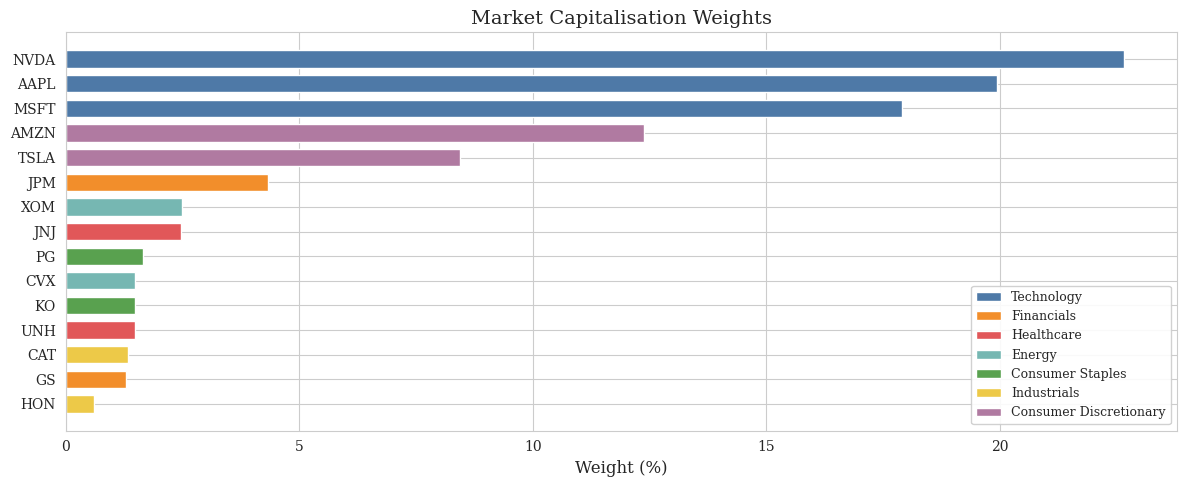

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
sorted_w = w_mkt.sort_values()
colors = [SECTOR_COLORS[SECTORS[t]] for t in sorted_w.index]
ax.barh(sorted_w.index, sorted_w.values * 100, color=colors, edgecolor='white', height=0.7)
ax.set_xlabel('Weight (%)')
ax.set_title('Market Capitalisation Weights')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in SECTOR_COLORS.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

## 1.5 Sample Covariance Matrix $\Sigma$

Weekly covariance matrix used in all BL computations. Annualised version ($\Sigma_{ann} = 52 \times \Sigma_{weekly}$) for display only.

In [11]:
Sigma_weekly = returns.cov()
Sigma_annual = Sigma_weekly * 52

min_eigenvalue = np.linalg.eigvalsh(Sigma_weekly).min()
print(f"Covariance matrix: {Sigma_weekly.shape[0]}x{Sigma_weekly.shape[1]}")
print(f"Min eigenvalue: {min_eigenvalue:.2e} -> {'PD' if min_eigenvalue > 0 else 'NOT PD'}")

Covariance matrix: 15x15
Min eigenvalue: 2.07e-04 -> PD


### Figure 5.1 — Correlation Heatmap

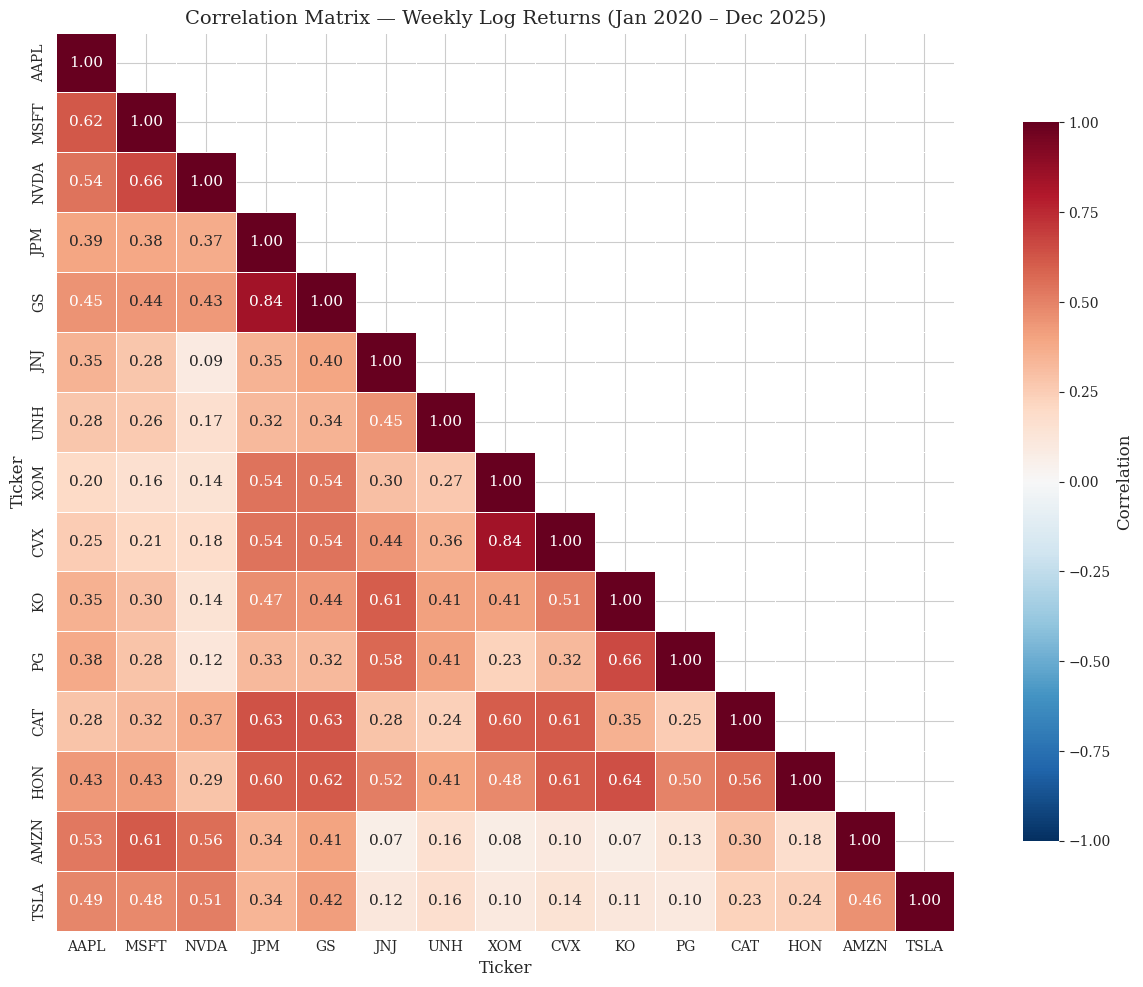

In [12]:
corr = returns.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'}, ax=ax)
ax.set_title('Correlation Matrix — Weekly Log Returns (Jan 2020 – Dec 2025)')
plt.tight_layout()
plt.show()

## 1.6 Risk Aversion Coefficient $\delta$

$$\delta = \frac{\bar{r}_{mkt} - r_f}{\sigma^2_{mkt}}$$

Calibrated from SPY weekly returns over the estimation window.

In [13]:
mu_mkt_weekly = returns_spy.mean()
var_mkt_weekly = returns_spy.var()
rf_mean_weekly = rf_weekly.mean()

delta = (mu_mkt_weekly - rf_mean_weekly) / var_mkt_weekly

mu_mkt_annual = mu_mkt_weekly * 52
vol_mkt_annual = np.sqrt(var_mkt_weekly * 52)

tbl = make_pretty("Parameter Dashboard",
    ["Parameter", "Value"],
    [["delta (risk aversion)", f"{delta:.4f}"],
     ["E[R_mkt] weekly", f"{mu_mkt_weekly:.6f}"],
     ["E[R_mkt] annualised", f"{mu_mkt_annual:.4f}"],
     ["Var_mkt weekly", f"{var_mkt_weekly:.6f}"],
     ["Vol_mkt annualised", f"{vol_mkt_annual:.4f}"],
     ["r_f weekly (mean)", f"{rf_mean_weekly:.6f}"],
     ["r_f annualised", f"{rf_annual_avg:.4f}"],
     ["Window", f"{returns.index[0].date()} to {returns.index[-1].date()}"],
     ["Observations", f"{len(returns)}"]],
    align_map={"Parameter": "l", "Value": "r"})
print(tbl)
print(f"\ndelta = {delta:.4f} implies {delta:.2f} units of excess return per unit of variance")

┌──────────────────────────────────────────────────┐
│               Parameter Dashboard                │
├───────────────────────┬──────────────────────────┤
│ Parameter             │                    Value │
├───────────────────────┼──────────────────────────┤
│ delta (risk aversion) │                   2.7717 │
│ E[R_mkt] weekly       │                 0.002660 │
│ E[R_mkt] annualised   │                   0.1383 │
│ Var_mkt weekly        │                 0.000765 │
│ Vol_mkt annualised    │                   0.1994 │
│ r_f weekly (mean)     │                 0.000541 │
│ r_f annualised        │                   0.0285 │
│ Window                │ 2020-01-07 to 2025-12-30 │
│ Observations          │                      313 │
└───────────────────────┴──────────────────────────┘

delta = 2.7717 implies 2.77 units of excess return per unit of variance


## 1.7 Equilibrium Returns $\Pi$

$$\Pi = \delta \, \Sigma \, w_{mkt}$$

Weekly implied equilibrium returns. Annualised ($\times 52$) for presentation.

In [14]:
Pi_weekly = delta * Sigma_weekly.values @ w_mkt.values
Pi_weekly = pd.Series(Pi_weekly, index=TICKERS)
Pi_annual = Pi_weekly * 52

w_eq = w_mkt.values  # equilibrium weights = market cap weights by BL construction

rows = []
for t in Pi_annual.sort_values(ascending=False).index:
    rows.append([t, SECTORS[t], Pi_annual[t]*100])

tbl = make_pretty("Equilibrium Returns (Annualised %)",
                  ["Ticker", "Sector", "Pi (%)"], rows,
                  align_map={"Ticker": "l", "Sector": "l"})
print(tbl)

┌──────────────────────────────────────────┐
│    Equilibrium Returns (Annualised %)    │
├────────┬────────────────────────┬────────┤
│ Ticker │ Sector                 │ Pi (%) │
├────────┼────────────────────────┼────────┤
│ TSLA   │ Consumer Discretionary │  37.24 │
│ NVDA   │ Technology             │  33.31 │
│ AMZN   │ Consumer Discretionary │  19.26 │
│ AAPL   │ Technology             │  18.42 │
│ MSFT   │ Technology             │  16.88 │
│ GS     │ Financials             │  15.25 │
│ JPM    │ Financials             │  12.65 │
│ CAT    │ Industrials            │  11.35 │
│ HON    │ Industrials            │   9.60 │
│ CVX    │ Energy                 │   8.11 │
│ UNH    │ Healthcare             │   8.07 │
│ XOM    │ Energy                 │   6.70 │
│ KO     │ Consumer Staples       │   4.88 │
│ PG     │ Consumer Staples       │   4.17 │
│ JNJ    │ Healthcare             │   4.13 │
└────────┴────────────────────────┴────────┘


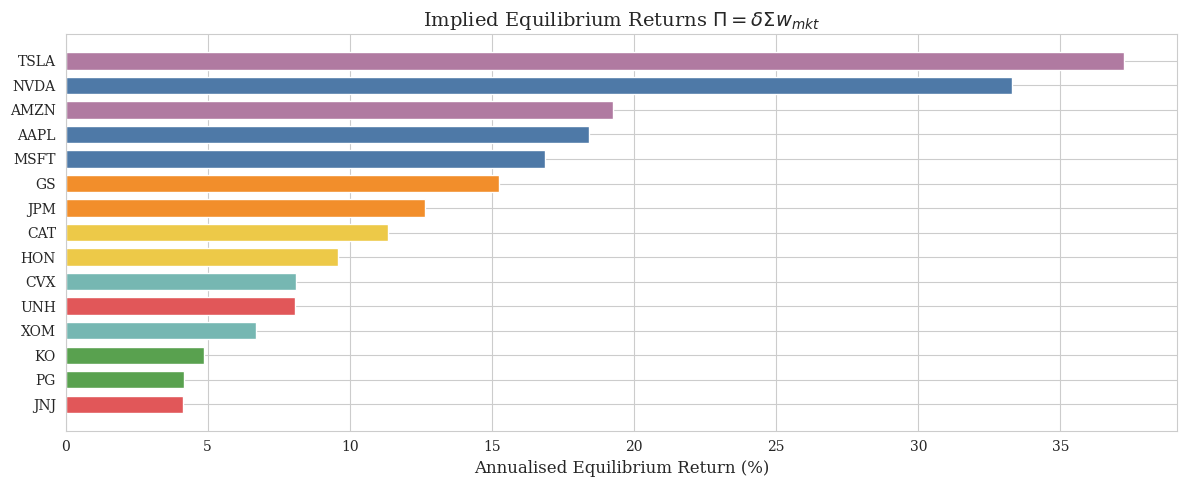

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
sorted_pi = Pi_annual.sort_values()
colors = [SECTOR_COLORS[SECTORS[t]] for t in sorted_pi.index]
ax.barh(sorted_pi.index, sorted_pi.values * 100, color=colors, edgecolor='white', height=0.7)
ax.set_xlabel('Annualised Equilibrium Return (%)')
ax.set_title('Implied Equilibrium Returns $\Pi = \delta \Sigma w_{mkt}$')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 1.8 Descriptive Statistics

### Table 5.1 — Descriptive Statistics Summary

In [18]:
all_assets = list(TICKERS) + [BENCHMARK_TICKER]
all_returns = log_returns_full.loc[BASELINE_START:BASELINE_END, all_assets].loc[common_idx]

desc = pd.DataFrame(index=all_assets)
desc['Ann. Return (%)'] = all_returns.mean() * 52 * 100
desc['Ann. Vol (%)'] = all_returns.std() * np.sqrt(52) * 100
desc['Sharpe'] = (all_returns.mean() - rf_weekly.mean()) / all_returns.std() * np.sqrt(52)
desc['Skewness'] = all_returns.skew()
desc['Kurtosis'] = all_returns.kurtosis()
desc['Min Weekly (%)'] = all_returns.min() * 100
desc['Max Weekly (%)'] = all_returns.max() * 100

styled = desc.style.format({
    'Ann. Return (%)': '{:.2f}', 'Ann. Vol (%)': '{:.2f}',
    'Sharpe': '{:.2f}', 'Skewness': '{:.2f}', 'Kurtosis': '{:.2f}',
    'Min Weekly (%)': '{:.2f}', 'Max Weekly (%)': '{:.2f}'
})
styled = styled.highlight_max(subset=['Ann. Return (%)', 'Sharpe'], color='#1b4332')
styled = styled.highlight_min(subset=['Ann. Return (%)', 'Sharpe'], color='#9b2335')
styled

,Ann. Return (%),Ann. Vol (%),Sharpe,Skewness,Kurtosis,Min Weekly (%),Max Weekly (%)
AAPL,22.00,30.41,0.63,-0.32,2.03,-20.22,13.89
MSFT,19.34,26.61,0.62,-0.08,1.61,-13.73,16.41
NVDA,57.37,49.56,1.10,-0.29,1.00,-22.29,22.58
JPM,16.81,30.37,0.46,-0.70,6.61,-26.28,16.81
GS,24.36,32.38,0.67,-0.27,2.54,-18.63,16.77
JNJ,8.82,19.06,0.32,0.55,8.58,-13.44,17.96
UNH,3.69,33.97,0.03,-0.90,11.73,-32.23,25.43
XOM,13.42,32.48,0.33,-0.54,5.48,-25.24,17.59
CVX,8.34,32.71,0.17,-0.25,8.78,-25.12,28.29
KO,7.14,20.12,0.22,-0.36,11.66,-17.78,18.07


### Cumulative Wealth — All Assets vs. SPY

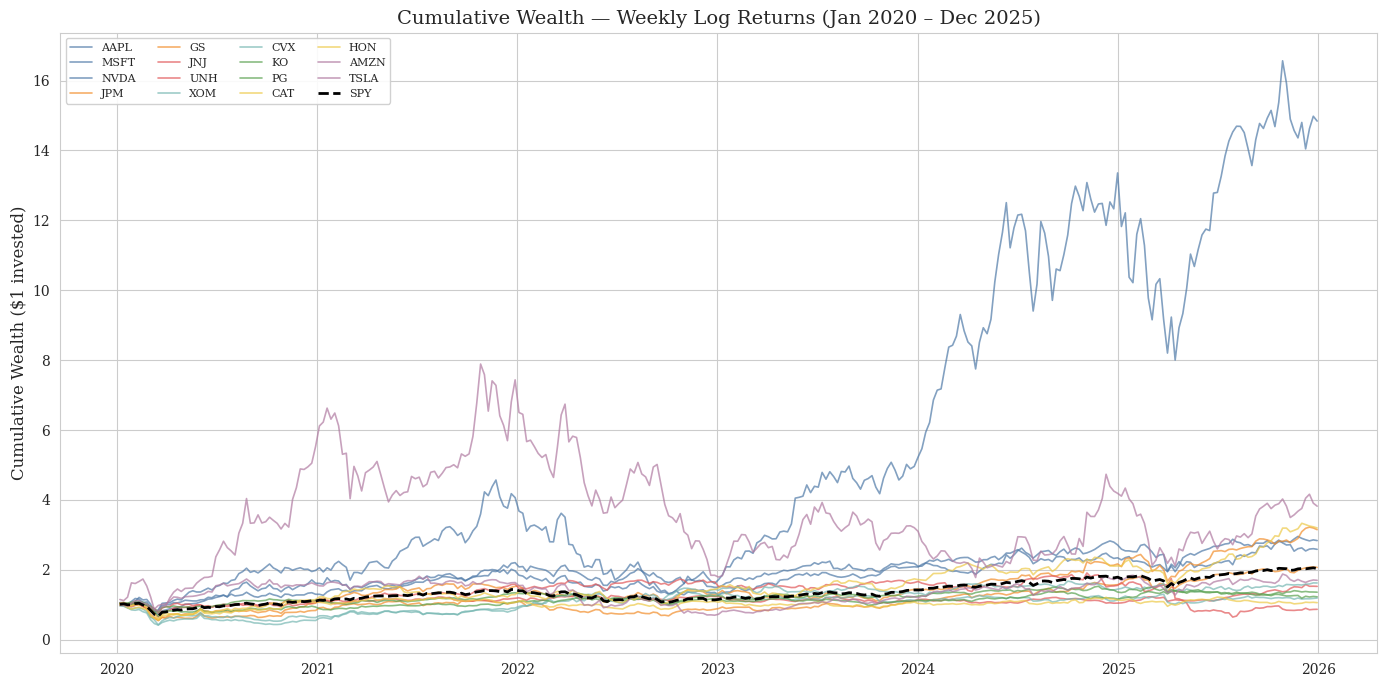

In [17]:
cumulative = (1 + all_returns).cumprod()

fig, ax = plt.subplots(figsize=(14, 7))
for t in TICKERS:
    ax.plot(cumulative.index, cumulative[t], label=t,
            color=SECTOR_COLORS[SECTORS[t]], alpha=0.7, linewidth=1.2)
ax.plot(cumulative.index, cumulative[BENCHMARK_TICKER], label='SPY',
        color='black', linestyle='--', linewidth=2)
ax.set_ylabel('Cumulative Wealth ($1 invested)')
ax.set_title('Cumulative Wealth — Weekly Log Returns (Jan 2020 – Dec 2025)')
ax.legend(ncol=4, fontsize=8, loc='upper left', framealpha=0.9)
ax.set_xlabel('')
plt.tight_layout()
plt.show()

---

*End of Section I — Data Acquisition and Preparation*

## 2. Section II — Pairwise Factor-Model Regressions